In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# 2. Import Library
# ==========================================================
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================================================
# 3. Membaca Dataset
# ==========================================================
folder_path = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Instagram"

embedding_df = pd.read_csv(os.path.join(folder_path, "ig_embed_lightgbm.csv"))
label_df = pd.read_csv(os.path.join(folder_path, "ig_pseudo.csv"))

print("Embedding :", embedding_df.shape)
print("Pseudo    :", label_df.shape)

Embedding : (25094, 769)
Pseudo    : (25094, 3)


In [4]:
# ==========================================================
# 4. Merge Dataset
# ==========================================================
df = pd.merge(
    embedding_df,
    label_df[["ig_clean", "label_sentimen", "confidence_score"]],
    on="ig_clean",
    how="inner"
)

print(df.head())
print(df.shape)

                                       ig_clean     emb_0     emb_1     emb_2  \
0                               🔥 alhamdulillah  0.006953 -0.137256 -0.541079   
1                                      gaskan 🔥  0.591783  0.446531 -0.500887   
2   nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲  0.266555 -0.661270 -0.788059   
3                            next deddy sitorus -0.673955  0.090875 -0.863588   
4  serem yaa kalau masa sudah tak terkendali 😢, -0.048852  0.004424 -0.684067   

      emb_3     emb_4     emb_5     emb_6     emb_7     emb_8  ...   emb_760  \
0 -0.999487 -1.265821 -1.593847  1.138782  0.282532  0.043134  ... -0.084328   
1 -0.744773 -0.283955 -1.234727  0.397072  1.046567  0.180212  ...  0.537831   
2  0.287385 -0.395038 -0.667398  0.164113  0.236695  0.571597  ...  0.843780   
3 -0.054947 -0.472445 -0.814360  0.400292  0.121890  0.339712  ...  2.008951   
4  0.082023 -0.523628 -0.673823  0.968572  0.647322  0.044698  ...  0.613438   

    emb_761   emb_762   emb_763 

In [5]:
# ==========================================================
# 5. Filter Confidence Score
# ==========================================================
# Gunakan jika ingin hanya memakai pseudo label yang yakin

df = df[df["confidence_score"] >= 0.80].reset_index(drop=True)

print("Jumlah data setelah filter :", len(df))

Jumlah data setelah filter : 19966


In [6]:
# ==========================================================
# 6. Menentukan Feature dan Label
# ==========================================================
embedding_cols = [col for col in df.columns if col.startswith("emb_")]

X = df[embedding_cols].values

y = df["label_sentimen"]

print("Jumlah fitur :", len(embedding_cols))
print("Shape X :", X.shape)

Jumlah fitur : 768
Shape X : (19966, 768)


In [7]:
# ==========================================================
# 7. Label Encoding
# ==========================================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label kelas :", encoder.classes_)

Label kelas : ['negative' 'neutral' 'positive']


In [8]:
# ==========================================================
# 8. Train Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (15972, 768)
Test  : (3994, 768)


In [9]:
# ==========================================================
# 9. Training LightGBM
# ==========================================================
model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.170230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 15972, number of used features: 768
[LightGBM] [Info] Start training from score -0.471859
[LightGBM] [Info] Start training from score -1.576006
[LightGBM] [Info] Start training from score -1.775735


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_class=3,
               objective='multiclass', random_state=42)

In [10]:
# ==========================================================
# 10. Prediksi
# ==========================================================
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
# ==========================================================
# 11. Evaluasi Model
# ==========================================================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print("HASIL EVALUASI LIGHTGBM")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.8951
Precision : 0.8974
Recall    : 0.8951
F1 Score  : 0.8917


In [12]:
# ==========================================================
# 12. Classification Report
# ==========================================================
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.89      0.98      0.93      2492
     neutral       0.90      0.80      0.85       826
    positive       0.93      0.71      0.81       676

    accuracy                           0.90      3994
   macro avg       0.91      0.83      0.86      3994
weighted avg       0.90      0.90      0.89      3994



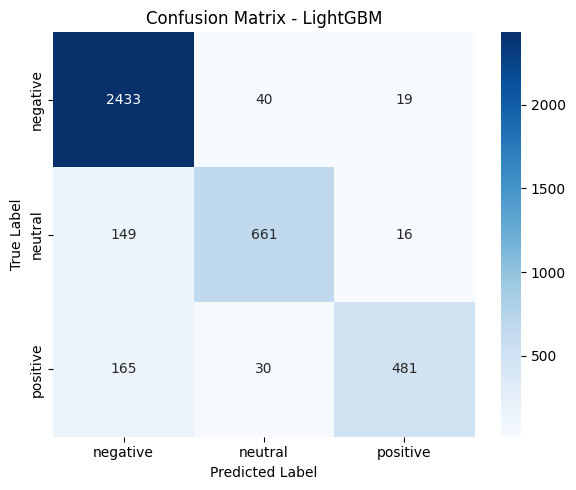

In [13]:
# ==========================================================
# 13. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# Prediksi Seluruh Dataset
# ==========================================================
df["prediksi"] = model.predict(X)

# Mengembalikan label angka menjadi label asli
df["prediksi"] = encoder.inverse_transform(df["prediksi"])

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ig_clean,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,label_sentimen,confidence_score,prediksi
0,🔥 alhamdulillah,0.006953,-0.137256,-0.541079,-0.999487,-1.265821,-1.593847,1.138782,0.282532,0.043134,...,-0.859102,-0.446931,0.396431,0.051657,-0.298981,0.066875,0.915009,positive,0.996476,positive
1,"nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲",0.266555,-0.661270,-0.788059,0.287385,-0.395038,-0.667398,0.164113,0.236695,0.571597,...,-0.227278,-0.537541,-0.299462,0.034086,-0.145742,-0.253568,0.414501,positive,0.995375,positive
2,next deddy sitorus,-0.673955,0.090875,-0.863588,-0.054947,-0.472445,-0.814360,0.400292,0.121890,0.339712,...,-0.078902,0.470270,-0.574810,-0.552539,-0.337390,-0.347627,0.623913,neutral,0.994973,neutral
3,"serem yaa kalau masa sudah tak terkendali 😢,",-0.048852,0.004424,-0.684067,0.082023,-0.523628,-0.673823,0.968572,0.647322,0.044698,...,-0.587059,-0.662865,-0.313832,0.119825,-0.119258,-0.310656,0.119383,negative,0.996316,negative
4,masuk pa eko 😂,0.947244,-0.971801,-0.407742,0.189195,-0.736957,-1.306344,1.421191,0.220324,0.478351,...,0.042689,-0.470127,-0.119138,-0.156024,-1.182205,0.305329,1.117978,neutral,0.934647,neutral


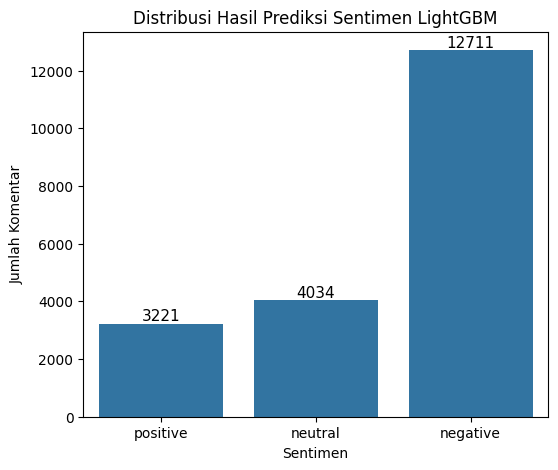

In [15]:
# ==========================================================
# Bar Chart + Jumlah
# ==========================================================
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="prediksi",
    order=["positive","neutral","negative"]
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribusi Hasil Prediksi Sentimen LightGBM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

plt.show()

In [16]:
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 19,966
label_sentimen
negative    12456
neutral      4129
positive     3381
Name: count, dtype: int64
